In [41]:
import pandas as pd
import os
import sys
import json
from pathlib import Path
import numpy as np

# Notebook is in notebooks/, so repo root is parent
REPO_ROOT = Path.cwd().parent
SRC_PATH = REPO_ROOT / "src"

# Insert src at the front of sys.path so imports work
sys.path.insert(0, str(SRC_PATH))

In [42]:
import importlib
import preprocessing.icd_entity_extraction as iee

importlib.reload(iee)

<module 'preprocessing.icd_entity_extraction' from '/Users/brandonng/Documents/GitHub/ClinicalDigitalTwin/src/preprocessing/icd_entity_extraction.py'>

In [43]:
from preprocessing.icd_entity_extraction import load_clinical_data

# Get repo root relative to the current notebook
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Load static preprocessing config
config_path = os.path.join(repo_root, "configs", "icdcode_extractor_params.json")
with open(config_path, "r") as f:
    config = json.load(f)

in_dir = os.path.join(repo_root, config["paths"]["in_dir"])

# Pass in_dir as the first argument
clinical_data = load_clinical_data(in_dir, config)
clinical_data.head(5)

,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,death_time,icu_stay_id,icu_intime,icu_outtime,icu_count,diagnosis,icd_codes
0,10049341,20677333.0,34255415.0,2171-04-07 17:48:00,2171-04-08 09:31:00,2171-04-08 00:26:00,2171-04-08 09:31:00,ASIAN,F,55.0,NaN,NaN,NaN,NaN,NaN,"['Chest pain, unspecified', 'Personal history ...","['78650', 'V103']"
1,10049341,NaN,35767475.0,2170-08-29 18:20:00,2170-08-29 22:46:00,NaN,NaN,ASIAN,F,NaN,NaN,NaN,NaN,NaN,NaN,"['PAINFUL RESPIRATION', 'PAIN IN LIMB', 'HX OF...","['78652', '7295', 'V103']"
2,10049341,NaN,36382949.0,2171-11-19 20:09:00,2171-11-20 00:03:00,NaN,NaN,ASIAN,F,NaN,NaN,NaN,NaN,NaN,NaN,['HEADACHE'],['7840']
3,10049341,NaN,36490047.0,2174-11-29 19:39:00,2174-11-30 00:49:00,NaN,NaN,ASIAN,F,NaN,NaN,NaN,NaN,NaN,NaN,['Pain in left foot'],['M79672']
4,10049341,NaN,37283116.0,2174-01-26 20:10:00,2174-01-27 00:34:00,NaN,NaN,ASIAN,F,NaN,NaN,NaN,NaN,NaN,NaN,"['Pain in right foot', 'Striking against or st...","['M79671', 'W228XXA']"


In [44]:
from preprocessing.icd_entity_extraction import clean_icd_codes

clinical_data['icd_codes'] = clinical_data['icd_codes'].apply(clean_icd_codes)
clinical_data.head(5)


,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,death_time,icu_stay_id,icu_intime,icu_outtime,icu_count,diagnosis,icd_codes
0,10049341,20677333.0,34255415.0,2171-04-07 17:48:00,2171-04-08 09:31:00,2171-04-08 00:26:00,2171-04-08 09:31:00,ASIAN,F,55.0,NaN,NaN,NaN,NaN,NaN,"['Chest pain, unspecified', 'Personal history ...","[786.50, V10.3]"
1,10049341,NaN,35767475.0,2170-08-29 18:20:00,2170-08-29 22:46:00,NaN,NaN,ASIAN,F,NaN,NaN,NaN,NaN,NaN,NaN,"['PAINFUL RESPIRATION', 'PAIN IN LIMB', 'HX OF...","[786.52, 729.5, V10.3]"
2,10049341,NaN,36382949.0,2171-11-19 20:09:00,2171-11-20 00:03:00,NaN,NaN,ASIAN,F,NaN,NaN,NaN,NaN,NaN,NaN,['HEADACHE'],[784.0]
3,10049341,NaN,36490047.0,2174-11-29 19:39:00,2174-11-30 00:49:00,NaN,NaN,ASIAN,F,NaN,NaN,NaN,NaN,NaN,NaN,['Pain in left foot'],[M79.672]
4,10049341,NaN,37283116.0,2174-01-26 20:10:00,2174-01-27 00:34:00,NaN,NaN,ASIAN,F,NaN,NaN,NaN,NaN,NaN,NaN,"['Pain in right foot', 'Striking against or st...","[M79.671, W22.8XXA]"


In [45]:
from preprocessing.icd_entity_extraction import map_codes_to_labels

clinical_data['labels'] = clinical_data['icd_codes'].apply(map_codes_to_labels)
clinical_data.head(5)


,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,death_time,icu_stay_id,icu_intime,icu_outtime,icu_count,diagnosis,icd_codes,labels
0,10049341,20677333.0,34255415.0,2171-04-07 17:48:00,2171-04-08 09:31:00,2171-04-08 00:26:00,2171-04-08 09:31:00,ASIAN,F,55.0,NaN,NaN,NaN,NaN,NaN,"['Chest pain, unspecified', 'Personal history ...","[786.50, V10.3]",[]
1,10049341,NaN,35767475.0,2170-08-29 18:20:00,2170-08-29 22:46:00,NaN,NaN,ASIAN,F,NaN,NaN,NaN,NaN,NaN,NaN,"['PAINFUL RESPIRATION', 'PAIN IN LIMB', 'HX OF...","[786.52, 729.5, V10.3]",[]
2,10049341,NaN,36382949.0,2171-11-19 20:09:00,2171-11-20 00:03:00,NaN,NaN,ASIAN,F,NaN,NaN,NaN,NaN,NaN,NaN,['HEADACHE'],[784.0],[]
3,10049341,NaN,36490047.0,2174-11-29 19:39:00,2174-11-30 00:49:00,NaN,NaN,ASIAN,F,NaN,NaN,NaN,NaN,NaN,NaN,['Pain in left foot'],[M79.672],[]
4,10049341,NaN,37283116.0,2174-01-26 20:10:00,2174-01-27 00:34:00,NaN,NaN,ASIAN,F,NaN,NaN,NaN,NaN,NaN,NaN,"['Pain in right foot', 'Striking against or st...","[M79.671, W22.8XXA]",[]


In [46]:
from preprocessing.icd_entity_extraction import onehot_labels

clinical_data = onehot_labels(clinical_data)
clinical_data.head(5)

,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,...,label_stemi,label_subsequent_mi,label_supraventricular_tachycardia,label_tia,label_unspecified_cardiac,label_unstable_angina,label_valvular_heart_disease,label_ventricular_arrhythmias,is_cardiovascular,is_specified_cardiac
0,10049341,20677333.0,34255415.0,2171-04-07 17:48:00,2171-04-08 09:31:00,2171-04-08 00:26:00,2171-04-08 09:31:00,ASIAN,F,55.0,...,0,0,0,0,0,0,0,0,0,0
1,10049341,NaN,35767475.0,2170-08-29 18:20:00,2170-08-29 22:46:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
2,10049341,NaN,36382949.0,2171-11-19 20:09:00,2171-11-20 00:03:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
3,10049341,NaN,36490047.0,2174-11-29 19:39:00,2174-11-30 00:49:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
4,10049341,NaN,37283116.0,2174-01-26 20:10:00,2174-01-27 00:34:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0


In [47]:
# Flatten labels from lists
all_labels = clinical_data['labels'].explode().dropna().astype(str).str.lower()

label_counts = all_labels.value_counts()
MIN_COUNT = 0  # keep frequent enough labels
label_df = label_counts[label_counts >= MIN_COUNT].reset_index()
label_df.columns = ['label', 'count']
label_df = label_df.sort_values('count', ascending=True) 
label_df.head(10)
# Label frequency distribution

,label,count
65,high_output_heart_failure,9
64,myocarditis,44
63,unstable_angina,78
62,subsequent_mi,82
61,coronary_aneurysm_dissection,131
60,end_stage_heart_failure,155
59,cardiomegaly,236
58,stable_angina,249
57,other_conduction_disorders,267
56,right_heart_failure,291


Top 10 labels:
                         label  count
0                 hypertension  99122
1      electrolyte_disturbance  53663
2            diabetes_mellitus  50087
3                       anemia  41883
4      coronary_artery_disease  32355
5       chronic_kidney_disease  30247
6  atrial_fibrillation_flutter  29224
7          acute_kidney_injury  24470
8  gi_bleed_or_hepatic_failure  15655
9        chronic_heart_failure  12911


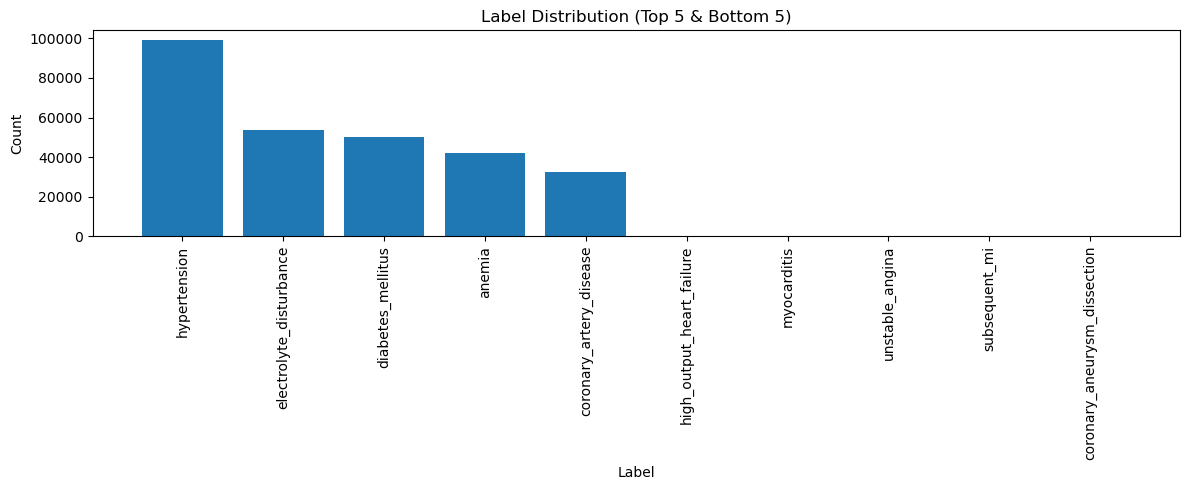

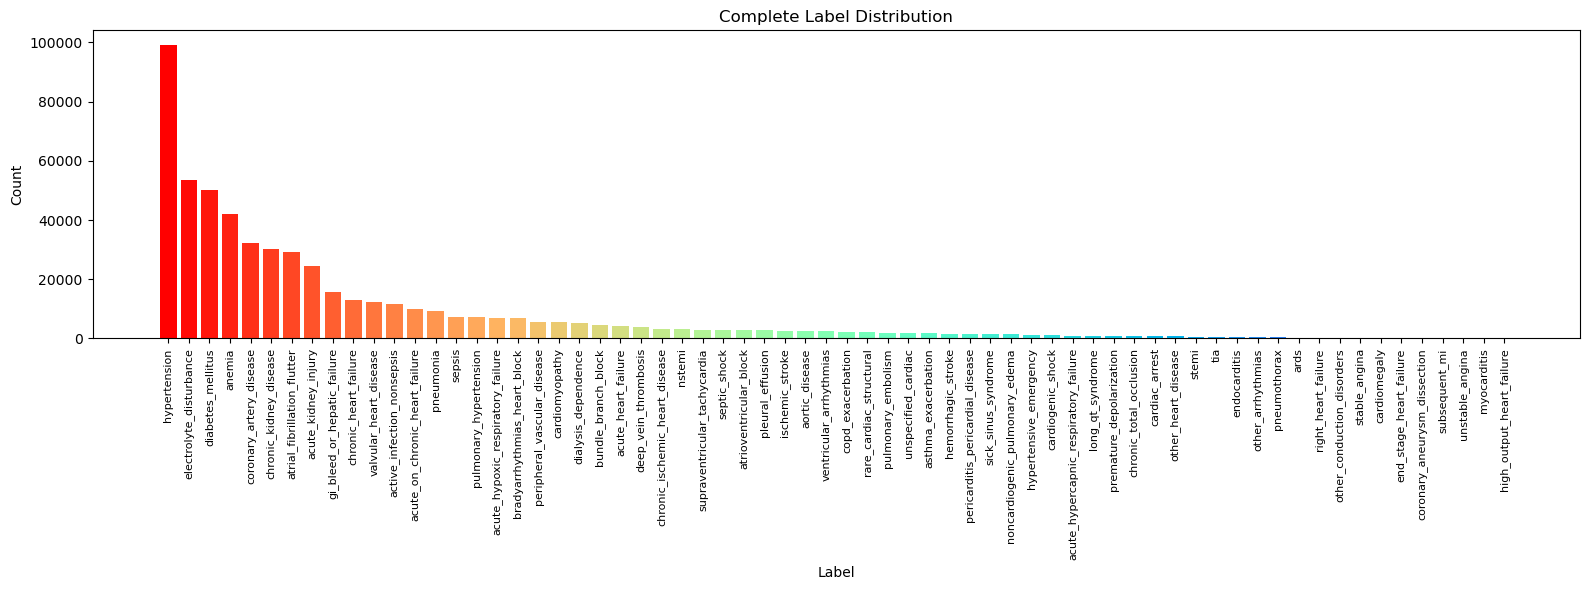

In [55]:
# Flatten labels from lists
all_labels = clinical_data['labels'].explode().dropna().astype(str).str.lower()

label_counts = all_labels.value_counts()
MIN_COUNT = 0  # keep frequent enough labels
label_df = label_counts[label_counts >= MIN_COUNT].reset_index()
label_df.columns = ['label', 'count']
label_df = label_df.sort_values('count', ascending=False) 

# Display top 10 labels
print("Top 10 labels:")
print(label_df.head(10))

# Get top 5 and bottom 5 labels by count
top_bottom_df = pd.concat([
    label_df.nlargest(5, 'count'),
    label_df.nsmallest(5, 'count')
])

# Plot top 5 and bottom 5
plt.figure(figsize=(12, 5))
plt.bar(top_bottom_df['label'], top_bottom_df['count'])
plt.xticks(rotation=90)
plt.title("Label Distribution (Top 5 & Bottom 5)")
plt.ylabel("Count")
plt.xlabel("Label")
plt.tight_layout()
plt.show()

# Plot all labels
plt.figure(figsize=(16, 6))
colors = plt.cm.rainbow(np.linspace(0, 1, len(label_df)))[::-1]
plt.bar(label_df['label'], label_df['count'], color=colors)
plt.xticks(rotation=90, fontsize=8)
plt.title("Complete Label Distribution")
plt.ylabel("Count")
plt.xlabel("Label")
plt.tight_layout()
plt.show()

In [49]:
clinical_data.columns

Index(['subject_id', 'hadm_id', 'ed_stay_id', 'ed_intime', 'ed_outtime',
       'hosp_admittime', 'hosp_dischtime', 'race', 'gender', 'anchor_age',
       'death_time', 'icu_stay_id', 'icu_intime', 'icu_outtime', 'icu_count',
       'diagnosis', 'icd_codes', 'labels', 'label_active_infection_nonsepsis',
       'label_acute_heart_failure',
       'label_acute_hypercapnic_respiratory_failure',
       'label_acute_hypoxic_respiratory_failure', 'label_acute_kidney_injury',
       'label_acute_on_chronic_heart_failure', 'label_anemia',
       'label_aortic_disease', 'label_ards', 'label_asthma_exacerbation',
       'label_atrial_fibrillation_flutter', 'label_atrioventricular_block',
       'label_bradyarrhythmias_heart_block', 'label_bundle_branch_block',
       'label_cardiac_arrest', 'label_cardiogenic_shock', 'label_cardiomegaly',
       'label_cardiomyopathy', 'label_chronic_heart_failure',
       'label_chronic_ischemic_heart_disease', 'label_chronic_kidney_disease',
       'label_chro

In [50]:
clinical_data.head()

,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,...,label_stemi,label_subsequent_mi,label_supraventricular_tachycardia,label_tia,label_unspecified_cardiac,label_unstable_angina,label_valvular_heart_disease,label_ventricular_arrhythmias,is_cardiovascular,is_specified_cardiac
0,10049341,20677333.0,34255415.0,2171-04-07 17:48:00,2171-04-08 09:31:00,2171-04-08 00:26:00,2171-04-08 09:31:00,ASIAN,F,55.0,...,0,0,0,0,0,0,0,0,0,0
1,10049341,NaN,35767475.0,2170-08-29 18:20:00,2170-08-29 22:46:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
2,10049341,NaN,36382949.0,2171-11-19 20:09:00,2171-11-20 00:03:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
3,10049341,NaN,36490047.0,2174-11-29 19:39:00,2174-11-30 00:49:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
4,10049341,NaN,37283116.0,2174-01-26 20:10:00,2174-01-27 00:34:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0


In [51]:
clinical_data.loc[:, ['subject_id', 'hadm_id', 'ed_stay_id'] + clinical_data.columns[clinical_data.columns.get_loc('label_active_infection_nonsepsis'):].tolist()]

,subject_id,hadm_id,ed_stay_id,label_active_infection_nonsepsis,label_acute_heart_failure,label_acute_hypercapnic_respiratory_failure,label_acute_hypoxic_respiratory_failure,label_acute_kidney_injury,label_acute_on_chronic_heart_failure,label_anemia,...,label_stemi,label_subsequent_mi,label_supraventricular_tachycardia,label_tia,label_unspecified_cardiac,label_unstable_angina,label_valvular_heart_disease,label_ventricular_arrhythmias,is_cardiovascular,is_specified_cardiac
0,10049341,20677333.0,34255415.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,10049341,NaN,35767475.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,10049341,NaN,36382949.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,10049341,NaN,36490047.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,10049341,NaN,37283116.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494226,19912537,28640361.0,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
494227,13141797,22643367.0,NaN,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
494228,11286186,23566382.0,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
494229,16578860,26155863.0,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1


In [ ]:
clinical_data['is_cardiovascular'].value_counts()
clinical_data['hadm_id', 'ed_stay_id']


is_cardiovascular
0    375009
1    119222
Name: count, dtype: int64

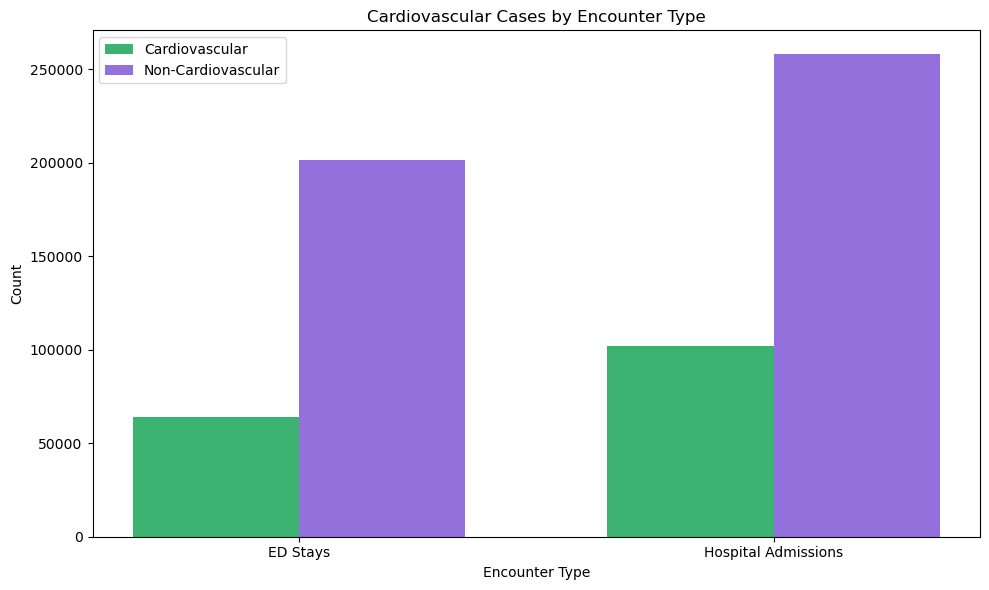

ED - Cardiovascular: 64,124, Non-Cardiovascular: 201,578
Hospital - Cardiovascular: 102,276, Non-Cardiovascular: 257,992


In [61]:
import matplotlib.pyplot as plt

# Count cardiovascular cases by encounter type
cardio_ed = clinical_data[clinical_data['ed_stay_id'].notna()]['is_cardiovascular'].value_counts()
cardio_hosp = clinical_data[clinical_data['hadm_id'].notna()]['is_cardiovascular'].value_counts()

# Prepare data for plotting
categories = ['ED Stays', 'Hospital Admissions']
cardio_counts = [cardio_ed[1], cardio_hosp[1]]  # is_cardiovascular = 1
non_cardio_counts = [cardio_ed[0], cardio_hosp[0]]  # is_cardiovascular = 0

# Create grouped bar chart
x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, cardio_counts, width, label='Cardiovascular', color='mediumseagreen')
plt.bar(x + width/2, non_cardio_counts, width, label='Non-Cardiovascular', color='mediumpurple')

plt.xlabel('Encounter Type')
plt.ylabel('Count')
plt.title('Cardiovascular Cases by Encounter Type')
plt.xticks(x, categories)
plt.legend()
plt.tight_layout()
plt.show()

# Print the counts
print(f"ED - Cardiovascular: {cardio_ed[1]:,}, Non-Cardiovascular: {cardio_ed[0]:,}")
print(f"Hospital - Cardiovascular: {cardio_hosp[1]:,}, Non-Cardiovascular: {cardio_hosp[0]:,}")

In [ ]:
# random forest or xgboost: ed vitals, ecg data -> predict diagnosis and machine measurements somehow...
# encoder (ecg data) ->
# ecg
# lstm?